# Évaluation finale du modèle — `/predict`

**Objectif :** évaluer sur le jeu de test réservé le modèle retenu dans les notebooks 08 et 10.

Le modèle, ses variables et ses hyperparamètres sont déjà figés. Le test n'a servi à aucun choix de modèle, de variable ou d'hyperparamètre, et ce notebook ne fait aucun nouveau choix.

## Imports

In [1]:
import json
import platform
from datetime import date

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression

from agritech.config import PATHS, SEED
from agritech.evaluation import cross_validate_regressor, regression_metrics
from agritech.modeling import RunInfo, log_model_run
from agritech.notification import notify
from agritech.predict_config import (
    PREDICT_CATEGORICAL,
    PREDICT_CV_FOLDS,
    PREDICT_CV_SHUFFLE,
    PREDICT_DATASET,
    PREDICT_FEATURES,
    PREDICT_NUMERIC,
    PREDICT_ROWS,
    PREDICT_SELECTED_FEATURES,
    PREDICT_TARGET,
    PREDICT_TEST_SIZE,
)
from agritech.preprocessing import PREPROCESSING_DESCRIPTION, build_pipeline
from agritech.tracking import run_tags, setup_mlflow
from agritech.training_data import feature_types, kfold_cv, load_dataset, protocol_params, split

# Données et découpage

Même dataset et même découpage que dans les notebooks 07 à 10 : 80 % des lignes pour le train, 20 % pour le test, avec `random_state=42`.

In [2]:
VARIABLES = PREDICT_SELECTED_FEATURES

df = load_dataset(PREDICT_DATASET, PREDICT_ROWS, PREDICT_FEATURES + [PREDICT_TARGET], non_negative=[PREDICT_TARGET])
X_train, X_test, y_train, y_test = split(df, PREDICT_FEATURES, PREDICT_TARGET, PREDICT_TEST_SIZE, SEED)
cv = kfold_cv(PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE, SEED)
categorielles, numeriques = feature_types(VARIABLES, PREDICT_CATEGORICAL, PREDICT_NUMERIC)

print(f"cible   : {PREDICT_TARGET}")
print(f"variables sélectionnées : {categorielles} (oui/non) et {numeriques} (numériques)")

fichier            : data/processed/predict_training_dataset.csv
lignes x colonnes  : (999769, 10)
valeurs manquantes : 0
valeurs < 0        : 0 (Yield_tons_per_hectare)
total   : 999769 lignes
X_train : (799815, 9)
X_test  : (199954, 9), réservé à l'évaluation finale
y_train : (799815,)
y_test  : (199954,)
validation croisée : KFold(n_splits=5, random_state=42, shuffle=True)
cible   : Yield_tons_per_hectare
variables sélectionnées : ['Fertilizer_Used', 'Irrigation_Used'] (oui/non) et ['Rainfall_mm', 'Temperature_Celsius'] (numériques)


In [3]:
# même expérience que les autres runs /predict, avec une étape dédiée à l'évaluation finale
experience = setup_mlflow("predict")
TAGS = run_tags(service="predict", stage="final_evaluation", notebook="11_predict_final_evaluation.ipynb")
PARAMS_PROTOCOLE = protocol_params(PREDICT_DATASET, X_train, X_test, PREDICT_TEST_SIZE, SEED, PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE)

expérience MLflow : oc_p12_agritech_predict


# Contrôles avant le test

Le chargement et le découpage ont déjà vérifié qu'il n'y a ni valeur manquante ni ligne commune entre train et
test. Avant toute prédiction, on contrôle en plus les tailles attendues et les variables du modèle final.

In [4]:
assert (len(X_train), len(X_test)) == (799_815, 199_954)
assert categorielles == ["Fertilizer_Used", "Irrigation_Used"]
assert numeriques == ["Rainfall_mm", "Temperature_Celsius"]

print("contrôles : OK")

contrôles : OK


# Modèle final

Le preprocessing commun et la régression linéaire sont réunis dans un seul pipeline.

Avant l'évaluation sur le test, on vérifie que ce pipeline redonne les scores de validation croisée du notebook 10 : c'est bien le modèle validé. Ce n'est pas une nouvelle comparaison.

In [5]:
modele_final = build_pipeline(LinearRegression(), categorielles, numeriques)
cv_final = cross_validate_regressor(modele_final, X_train[VARIABLES], y_train, cv)

print(f"validation croisée : RMSE {cv_final['cv_rmse_mean']:.6f} | MAE {cv_final['cv_mae_mean']:.6f} | R² {cv_final['cv_r2_mean']:.5f}")

# scores de la régression linéaire sur les variables sélectionnées, dans le notebook 10
assert round(cv_final["cv_rmse_mean"], 6) == 0.500332
assert round(cv_final["cv_mae_mean"], 6) == 0.399292
assert round(cv_final["cv_r2_mean"], 5) == 0.91289

validation croisée : RMSE 0.500332 | MAE 0.399292 | R² 0.91289


In [6]:
# preprocessing et régression appris ensemble, une seule fois, sur tout le train
modele_final.fit(X_train[VARIABLES], y_train)

assert type(modele_final["model"]) is LinearRegression
assert modele_final["model"].get_params() == LinearRegression().get_params()  # hyperparamètres par défaut
assert list(modele_final.feature_names_in_) == VARIABLES

encodeur = modele_final["preprocessing"].named_transformers_["categorical"]
print("colonnes vues par le modèle :", list(modele_final["preprocessing"].get_feature_names_out()))
print("modalités apprises sur le train :", {nom: modalites.tolist() for nom, modalites in zip(categorielles, encodeur.categories_)})

colonnes vues par le modèle : ['categorical__Fertilizer_Used_False', 'categorical__Fertilizer_Used_True', 'categorical__Irrigation_Used_False', 'categorical__Irrigation_Used_True', 'numeric__Rainfall_mm', 'numeric__Temperature_Celsius']
modalités apprises sur le train : {'Fertilizer_Used': [False, True], 'Irrigation_Used': [False, True]}


On mesure aussi le modèle final sur le train, c'est-à-dire sur les données qui ont servi à l'entraîner. Ces scores serviront de point de comparaison avec ceux du test.

In [7]:
# scores du modèle final sur les données qui ont servi à l'entraîner
predictions_train = modele_final.predict(X_train[VARIABLES])
metriques_train = regression_metrics(y_train, predictions_train, prefix="train")

print(f"train : RMSE {metriques_train['train_rmse']:.6f} | MAE {metriques_train['train_mae']:.6f} | R² {metriques_train['train_r2']:.5f}")

train : RMSE 0.500330 | MAE 0.399291 | R² 0.91289


**Observations :**

- Les scores sur le train sont quasi identiques à ceux de la validation croisée : aucun signe de surapprentissage n'apparaît.
- C'est attendu pour une régression linéaire qui n'utilise que 4 variables, soit 6 colonnes après encodage, et apprend sur près de 800 000 lignes.

# Évaluation sur le test

Le modèle entraîné sur tout le train prédit le rendement des lignes du test. Le pipeline réutilise l'encodage appris sur le train, sans le modifier.

In [8]:
predictions_test = modele_final.predict(X_test[VARIABLES])
metriques_test = regression_metrics(y_test, predictions_test)

print(f"test : RMSE {metriques_test['test_rmse']:.6f} | MAE {metriques_test['test_mae']:.6f} | R² {metriques_test['test_r2']:.5f}")

test : RMSE 0.499268 | MAE 0.398338 | R² 0.91323


In [9]:
log_model_run(
    RunInfo(
        "linear_regression_selected_features_final_test",
        "selected_features",
        TAGS | {"mlflow.note.content": "Évaluation finale sur le test réservé : régression linéaire sur les 4 variables sélectionnées, entraînée sur tout le train."},
        PARAMS_PROTOCOLE,
        {"trained_on": "full_train", "evaluated_on": "reserved_test"},
    ),
    modele_final,
    X_train[VARIABLES],
    categorielles,
    numeriques,
    cv_final | metriques_test,
)

# Comparaison avec la validation croisée

Le test ne sert pas à choisir : on regarde seulement si ses scores restent proches de ceux de la validation croisée.

In [10]:
comparaison = pd.DataFrame(
    {
        "CV train": [cv_final["cv_rmse_mean"], cv_final["cv_mae_mean"], cv_final["cv_r2_mean"]],
        "écart-type entre folds": [cv_final["cv_rmse_std"], cv_final["cv_mae_std"], cv_final["cv_r2_std"]],
        "Test final": [metriques_test["test_rmse"], metriques_test["test_mae"], metriques_test["test_r2"]],
    },
    index=pd.Index(["RMSE", "MAE", "R²"], name="métrique"),
)
comparaison["écart test − CV"] = comparaison["Test final"] - comparaison["CV train"]
comparaison.round(6)

,CV train,écart-type entre folds,Test final,écart test − CV
métrique,,,,
RMSE,0.500332,0.000896,0.499268,-0.001064
MAE,0.399292,0.000698,0.398338,-0.000954
R²,0.912890,0.000285,0.913235,0.000345


**Observations :**

- Les scores du test sont très proches de ceux de la validation croisée, et même légèrement meilleurs.
- Les écarts restent du même ordre que la variation d'un fold à l'autre : sur des données qui n'ont pas servi à l'entraînement, le modèle se comporte comme en validation croisée.

# Analyse des erreurs

Pour chaque prédiction du test : **résidu = rendement réel − rendement prédit**. Un résidu positif signifie que le modèle a prédit trop bas, un résidu négatif qu'il a prédit trop haut.

La figure de gauche montre la distribution des résidus. Celle de droite montre la taille de l'erreur (le résidu sans son signe) selon le rendement réel : les lignes sont regroupées par tranches de 0,5 t/ha, avec pour chaque tranche l'erreur absolue moyenne et son écart-type.

In [11]:
residus = y_test - predictions_test

print(f"résidu moyen : {residus.mean():+.4f} t/ha")
print(f"erreur absolue ≤ 0,5 t/ha : {(residus.abs() <= 0.5).mean():.1%} des lignes | ≤ 1 t/ha : {(residus.abs() <= 1).mean():.1%}")

résidu moyen : +0.0001 t/ha
erreur absolue ≤ 0,5 t/ha : 68.3% des lignes | ≤ 1 t/ha : 95.5%


In [12]:
erreurs = pd.DataFrame({"rendement_reel": y_test, "erreur_absolue": residus.abs()})
tranches = pd.cut(erreurs["rendement_reel"], bins=[i * 0.5 for i in range(21)], right=False)  # tranches de 0,5 t/ha

par_tranche = erreurs.groupby(tranches, observed=True).agg(
    lignes=("erreur_absolue", "size"),
    rendement_moyen=("rendement_reel", "mean"),
    erreur_moyenne=("erreur_absolue", "mean"),
    ecart_type=("erreur_absolue", "std"),
)

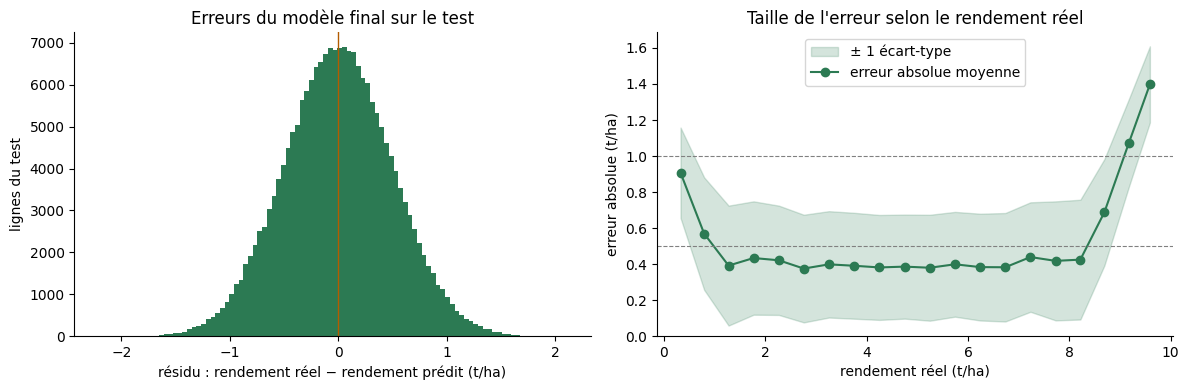

In [13]:
figure, (gauche, droite) = plt.subplots(1, 2, figsize=(12, 4))

# à gauche : distribution des résidus
gauche.hist(residus, bins=100, color="#2c7a53")
gauche.axvline(0, color="#b35c00", linewidth=1)
gauche.set_xlabel("résidu : rendement réel − rendement prédit (t/ha)")
gauche.set_ylabel("lignes du test")
gauche.set_title("Erreurs du modèle final sur le test")

# à droite : taille de l'erreur par tranche de rendement réel
droite.fill_between(
    par_tranche["rendement_moyen"],
    par_tranche["erreur_moyenne"] - par_tranche["ecart_type"],
    par_tranche["erreur_moyenne"] + par_tranche["ecart_type"],
    color="#2c7a53",
    alpha=0.2,
    label="± 1 écart-type",
)
droite.plot(par_tranche["rendement_moyen"], par_tranche["erreur_moyenne"], color="#2c7a53", marker="o", label="erreur absolue moyenne")
for niveau in [0.5, 1]:
    droite.axhline(niveau, color="grey", linestyle="--", linewidth=0.8)
droite.set_ylim(bottom=0)
droite.set_xlabel("rendement réel (t/ha)")
droite.set_ylabel("erreur absolue (t/ha)")
droite.set_title("Taille de l'erreur selon le rendement réel")
droite.legend(loc="upper center")

for axes in (gauche, droite):
    axes.spines[["top", "right"]].set_visible(False)
figure.tight_layout()
plt.show()

**Observations :**

- Le résidu moyen est presque nul et l'histogramme est centré sur zéro : le modèle ne semble pas avoir tendance à prédire systématiquement trop haut ou trop bas.
- 68,3 % des prédictions sont à moins de 0,5 t/ha de la vraie valeur, et 95,5 % à moins de 1 t/ha.
- Entre 1 et 8,5 t/ha, où se trouvent presque toutes les lignes du test, l'erreur absolue moyenne reste stable, autour de 0,4 t/ha.
- Elle augmente aux deux extrémités : plus de 0,5 t/ha sous 1 t/ha et au-delà de 8,5 t/ha, plus de 1 t/ha au-delà de 9 t/ha. Ces tranches contiennent toutefois peu de lignes : la hausse ne concerne qu'une petite partie des prédictions.

# Diagnostic des 231 rendements négatifs

Ces 231 lignes ont été retirées du dataset d'entraînement par le notebook 06, car leur rendement original est négatif. Elles ne font pas partie du test.

On affiche toutes ces lignes avec la prédiction du modèle final, sans rien réentraîner.

In [14]:
negatifs = pd.read_csv(PATHS.data_processed / "predict_negative_yield_rows.csv")
assert len(negatifs) == 231 and (negatifs[PREDICT_TARGET] < 0).all()
assert negatifs[VARIABLES].notna().all().all()

# une prédiction pour chacune des 231 lignes, sans aucun filtre
negatifs["prédiction"] = modele_final.predict(negatifs[VARIABLES])

# copie pour l'affichage : toutes les colonnes d'origine, rendements renommés, valeurs arrondies
affichage = negatifs.rename(
    columns={PREDICT_TARGET: "rendement original (t/ha)", "prédiction": "rendement prédit (t/ha)"}
).round(3)

In [15]:
affichage.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,rendement original (t/ha),rendement prédit (t/ha)
0,East,Peaty,Cotton,101.019,33.804,False,False,Rainy,117,-0.007,1.184
1,South,Chalky,Rice,108.805,18.004,False,False,Sunny,86,-0.061,0.908
2,East,Chalky,Soybean,168.121,38.473,False,False,Cloudy,111,-0.120,1.612
3,North,Silt,Wheat,156.608,16.610,False,False,Sunny,129,-0.193,1.119
4,South,Chalky,Maize,177.481,27.720,False,False,Sunny,94,-0.010,1.445


In [16]:
print(f"lignes analysées : {len(negatifs)}")
print(f"prédictions négatives : {(negatifs['prédiction'] < 0).sum()}")

resume = negatifs[[PREDICT_TARGET, "prédiction"]].agg(["min", "mean", "median", "max"]).T
resume.index = ["rendement original (t/ha)", "rendement prédit (t/ha)"]
resume.columns = ["min", "moyenne", "médiane", "max"]
resume.round(3)

lignes analysées : 231
prédictions négatives : 0


,min,moyenne,médiane,max
rendement original (t/ha),-1.148,-0.196,-0.135,-0.000
rendement prédit (t/ha),0.817,1.131,1.109,1.815


**Observations :**

- Ces 231 lignes avaient un rendement négatif dans les données originales.
- Avec les mêmes conditions, le modèle final prédit au contraire des rendements faibles mais toujours positifs.
- Cela renforce l'hypothèse que les rendements négatifs sont des anomalies dans les données.

# Sauvegarde du modèle final

Le pipeline complet (preprocessing et régression linéaire), entraîné sur le train uniquement, est sauvegardé avec `joblib` dans `models/`. Un fichier JSON l'accompagne : variables, protocole et scores sur le test.

On recharge ensuite le fichier dans un nouvel objet et on vérifie qu'il redonne les mêmes prédictions.

In [17]:
DOSSIER_MODELES = PATHS.root / "models"
DOSSIER_MODELES.mkdir(exist_ok=True)
chemin_modele = DOSSIER_MODELES / "predict_model.joblib"
chemin_metadonnees = DOSSIER_MODELES / "predict_model_metadata.json"

# pipeline complet (preprocessing + régression linéaire), entraîné sur le train uniquement
joblib.dump(modele_final, chemin_modele)

protocole = protocol_params(PREDICT_DATASET, X_train, X_test, PREDICT_TEST_SIZE, SEED, PREDICT_CV_FOLDS, PREDICT_CV_SHUFFLE)
metadonnees = {
    "service": "predict",
    "model_type": type(modele_final["model"]).__name__,
    "artifact": chemin_modele.name,
    "target": PREDICT_TARGET,
    "features": VARIABLES,
    "categorical_features": categorielles,
    "numeric_features": numeriques,
    "categorical_values": {nom: modalites.tolist() for nom, modalites in zip(categorielles, encodeur.categories_)},
    "preprocessing": PREPROCESSING_DESCRIPTION,
    "training_dataset": protocole["dataset"],
    "n_train": protocole["n_train"],
    "n_test": protocole["n_test"],
    "test_size": protocole["test_size"],
    "random_state": protocole["random_state"],
    "cv_folds": protocole["cv_folds"],
    "trained_on": "train_only",
    "final_test_metrics": {
        "rmse": metriques_test["test_rmse"],
        "mae": metriques_test["test_mae"],
        "r2": metriques_test["test_r2"],
    },
    "notebook": "notebooks/11_predict_final_evaluation.ipynb",
    "created_on": date.today().isoformat(),
    "versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
}
chemin_metadonnees.write_text(json.dumps(metadonnees, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

print("modèle sauvegardé :", chemin_modele.relative_to(PATHS.root))
print("métadonnées       :", chemin_metadonnees.relative_to(PATHS.root))

modèle sauvegardé : models/predict_model.joblib
métadonnées       : models/predict_model_metadata.json


In [18]:
# rechargement dans un nouvel objet, puis prédiction sur 1 000 lignes fixes du test (une toutes les 200)
modele_recharge = joblib.load(chemin_modele)
echantillon = X_test[VARIABLES].iloc[::200]

assert [nom for nom, _ in modele_recharge.steps] == ["preprocessing", "model"]
assert type(modele_recharge["model"]) is LinearRegression
assert list(modele_recharge.feature_names_in_) == VARIABLES
assert json.loads(chemin_metadonnees.read_text(encoding="utf-8"))["features"] == VARIABLES
assert np.allclose(modele_recharge.predict(echantillon), predictions_test[::200])

print(f"vérification après rechargement : OK ({len(echantillon)} prédictions identiques)")

vérification après rechargement : OK (1000 prédictions identiques)


# Conclusion

**Observations :**

- modèle final de `/predict` : `LinearRegression` sur les 4 variables sélectionnées, `Rainfall_mm`, `Temperature_Celsius`, `Fertilizer_Used` et `Irrigation_Used` ;
- train : RMSE 0,500330 t/ha, MAE 0,399291 t/ha, R² 0,91289, quasi identiques à la validation croisée ;
- validation croisée sur le train : RMSE 0,500332 t/ha, MAE 0,399292 t/ha, R² 0,91289 ;
- test final : RMSE 0,499268 t/ha, MAE 0,398338 t/ha, R² 0,91323, cohérents avec la validation croisée ;
- le test n'a servi à aucun choix de modèle, de variable ou d'hyperparamètre : ce notebook est l'évaluation finale du modèle déjà figé ;
- pour les 231 lignes à rendement négatif, le modèle prédit des rendements faibles mais toujours positifs : ces valeurs négatives ressemblent à des anomalies dans les données.

La modélisation de `/predict` est terminée.

In [19]:
notify("Agritech /predict", f"Évaluation finale terminée — RMSE test {metriques_test['test_rmse']:.4f} t/ha, R² {metriques_test['test_r2']:.4f}")